In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000, centers=3,n_features=2)

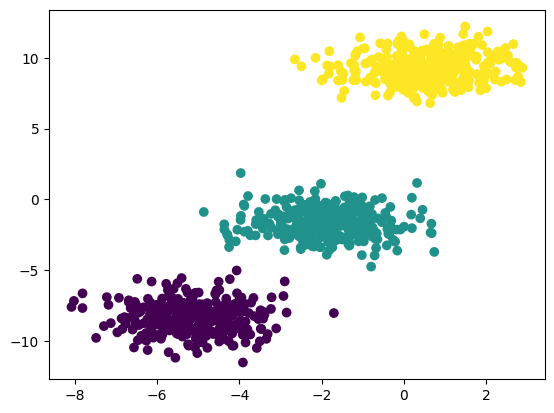

In [3]:
plt.scatter(X[:,0],X[:,1],c=y)

In [5]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [6]:
from sklearn.model_selection import train_test_split


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)


In [8]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [9]:
from sklearn.cluster import KMeans


In [10]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [25]:
wcss = []
for k in range (1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans)

In [26]:
wcss

[KMeans(n_clusters=1),
 KMeans(n_clusters=2),
 KMeans(n_clusters=3),
 KMeans(n_clusters=4),
 KMeans(n_clusters=5),
 KMeans(n_clusters=6),
 KMeans(n_clusters=7),
 KMeans(),
 KMeans(n_clusters=9),
 KMeans(n_clusters=10)]

In [11]:
wcss

[1339.9999999999995,
 399.86337834751686,
 119.36328638830594,
 97.4708012481375,
 73.3231520635306,
 67.03431822446385,
 46.12130868932633,
 40.14628209634804,
 37.059572695868596,
 31.09323193580906]

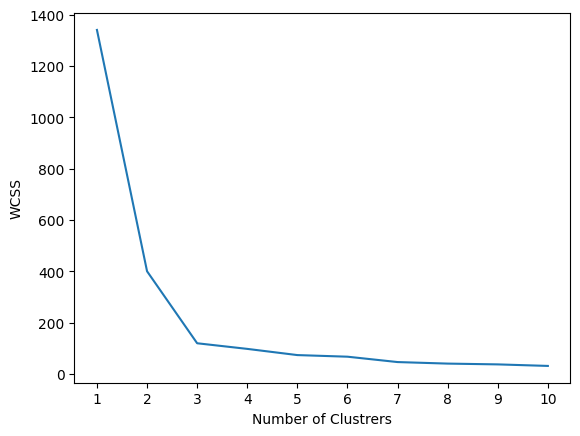

In [12]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [13]:
kmeans=KMeans(n_clusters=3,init="k-means++")


In [14]:
kmeans.fit_predict(X_train_scaled)


array([0, 1, 0, 1, 1, 1, 1, 1, 2, 0, 2, 2, 0, 1, 0, 1, 0, 0, 0, 2, 1, 1,
       2, 2, 0, 0, 1, 0, 1, 2, 0, 2, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 1, 1,
       2, 2, 1, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 0, 0, 0, 2, 1, 0, 0,
       1, 2, 0, 1, 1, 0, 1, 0, 1, 1, 1, 2, 1, 0, 2, 1, 1, 1, 0, 1, 2, 0,
       0, 0, 2, 0, 1, 1, 2, 0, 1, 2, 0, 0, 2, 1, 1, 2, 2, 2, 0, 0, 0, 1,
       2, 2, 1, 2, 2, 1, 1, 1, 1, 2, 0, 1, 2, 0, 0, 1, 0, 0, 2, 2, 2, 0,
       0, 1, 2, 2, 1, 2, 1, 2, 0, 1, 2, 1, 2, 0, 0, 1, 1, 0, 1, 2, 2, 2,
       2, 1, 1, 1, 1, 0, 1, 0, 2, 2, 0, 0, 1, 0, 2, 1, 2, 2, 1, 1, 2, 0,
       2, 2, 0, 0, 0, 0, 1, 2, 2, 1, 2, 2, 1, 2, 1, 2, 2, 0, 2, 1, 0, 1,
       2, 1, 2, 1, 2, 0, 2, 2, 1, 1, 0, 2, 0, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 2, 2, 0, 1, 0, 0, 0, 0, 1, 2,
       2, 2, 2, 0, 2, 2, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 1, 1, 2, 1, 0, 2, 2, 0, 2, 1,
       1, 0, 2, 1, 0, 2, 0, 2, 0, 2, 0, 0, 2, 0, 0,

In [15]:
y_pred=kmeans.predict(X_test_scaled)


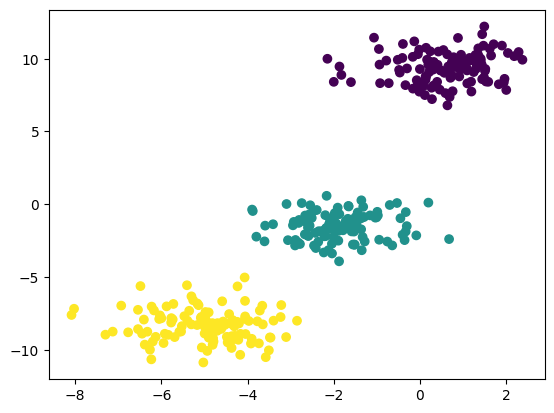

In [16]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)


In [17]:
## kneelocator
!pip install kneed

In [18]:
from kneed import KneeLocator


In [19]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")


In [20]:
kl.elbow


np.int64(3)

In [21]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [22]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [23]:
silhouette_coefficients

[0.6201888616707484,
 0.6843167876968913,
 0.5806470791049669,
 0.526035287747908,
 0.46274059647139776,
 0.4447866777557521,
 0.43615845426100996,
 0.42621658246823546,
 0.41760158543797765]

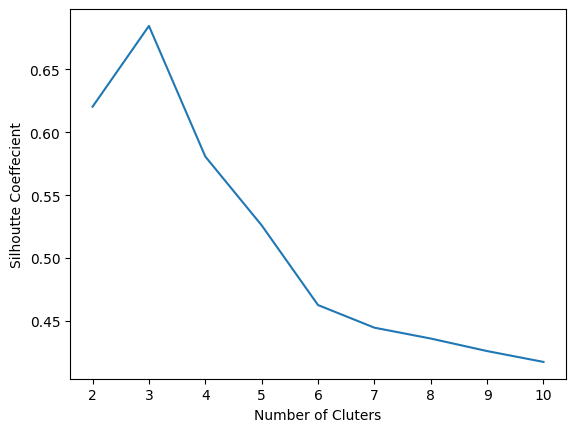

In [24]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()